#1. Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

#2. Load Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


#3. Select 3 Classes

In [3]:
selected_classes = [0, 3, 5]

def filter_classes(x, y, classes):
    mask = np.isin(y, classes).flatten()
    return x[mask], y[mask]

x_train, y_train = filter_classes(x_train, y_train, selected_classes)
x_test, y_test = filter_classes(x_test, y_test, selected_classes)

# Remap labels
label_map = {0:0, 3:1, 5:2}
y_train = np.array([label_map[i[0]] for i in y_train])
y_test = np.array([label_map[i[0]] for i in y_test])

#4. Train–Validation Split

In [4]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

#5. OpenCV Preprocessing

In [5]:
IMG_SIZE = 64

def preprocess_images(images):
    processed = []

    for img in images:
        # Read (already loaded, simulate OpenCV processing)

        # Resize
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Convert BGR → RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Normalize
        img = img / 255.0

        processed.append(img)

    return np.array(processed)

x_train = preprocess_images(x_train)
x_val = preprocess_images(x_val)
x_test = preprocess_images(x_test)

#6. One-Hot Encoding

In [6]:
y_train = to_categorical(y_train, 3)
y_val = to_categorical(y_val, 3)
y_test = to_categorical(y_test, 3)

#7. CNN Model

In [7]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,587 (2.61 MB)

 Trainable params: 683,587 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

#8. Train Model

In [8]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 91s 235ms/step - accuracy: 0.5880 - loss: 0.7793 - val_accuracy: 0.6867 - val_loss: 0.6180
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 116s 311ms/step - accuracy: 0.6802 - loss: 0.6414 - val_accuracy: 0.6780 - val_loss: 0.6380
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 109s 224ms/step - accuracy: 0.7255 - loss: 0.5753 - val_accuracy: 0.7407 - val_loss: 0.5325
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 86s 228ms/step - accuracy: 0.7549 - loss: 0.5332 - val_accuracy: 0.7593 - val_loss: 0.5207
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 84s 224ms/step - accuracy: 0.7732 - loss: 0.5088 - val_accuracy: 0.7577 - val_loss: 0.5262
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 84s 223ms/step - accuracy: 0.7870 - loss: 0.4695 - val_accuracy: 0.7490 - val_loss: 0.5694
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 144s 227ms/step - accuracy: 0.8067 - loss: 0.4375 - val_accuracy: 0.7877 - val_loss: 0.4699
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 142s 227ms/step - accuracy: 0.8223 - los

#9. Evaluation

In [9]:
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.7873 - loss: 0.5231
Test Accuracy: 0.7873333096504211
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step


#10. Confusion Matrix

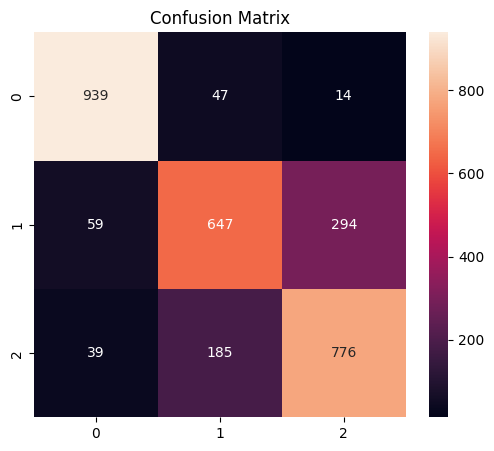

In [10]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

#11. Precision & Recall

In [11]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      1000
           1       0.74      0.65      0.69      1000
           2       0.72      0.78      0.74      1000

    accuracy                           0.79      3000
   macro avg       0.79      0.79      0.79      3000
weighted avg       0.79      0.79      0.79      3000



#12. Display Predictions

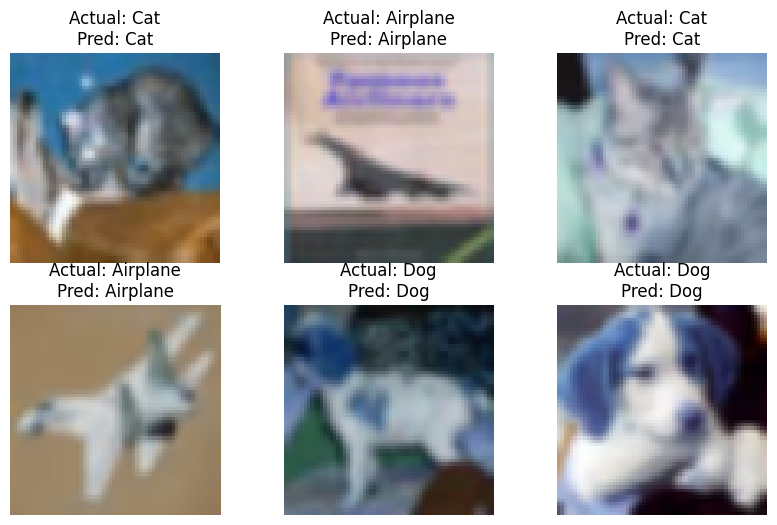

In [12]:
labels = ["Airplane", "Cat", "Dog"]

plt.figure(figsize=(10,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x_test[i])
    plt.title(f"Actual: {labels[y_true[i]]}\nPred: {labels[y_pred_classes[i]]}")
    plt.axis('off')

plt.show()